# 02 · Experten + Gating (Track B: SQI-gated Mixture of Experts)

**Bachelorarbeit: AF-Detektion in kontaktlosen Signalen · Nik Büttner · RWTH Aachen**

Dieses Notebook setzt die von Blaß gewünschte Architektur zusammen und wertet sie aus:

1. **Drei Experten** (cECG / PPG / BCG) liefern je eine fensterweise AF-Wahrscheinlichkeit.
2. Das **Gating-Netz** sagt aus den SQIs den Zuverlässigkeits-Fehler jeder Modalität
   vorher (Ziel aus dem GT-EKG, Bachelet-Stil) und macht daraus Gewichte.
3. **Gewichtete Fusion** → fensterweise AF-Entscheidung.

Alles läuft **leckagefrei**: patientenweise LOPO-CV (kein Patient in Train *und* Test),
Out-of-Fold-Experten-Outputs fürs Gate, und das GT-EKG fließt **nur** ins Trainings-Ziel
des Gates — nie in den Test-Pfad.

> **Voraussetzung:** `01_features_sqi.ipynb` wurde gelaufen (Feature-Tabelle liegt im
> `data/`-Ordner). Für die Reliability-Tabelle wird `neurokit2` benötigt (GT-R-Zacken);
> ohne neurokit2 greift ein einfacher Fallback-Detektor.


& c:\Users\sshuser\Documents\BA\.venv\Scripts\Activate.ps1

Start-Process -FilePath "c:\Users\sshuser\Documents\BA\.venv\Scripts\jupyter.exe" `
  -ArgumentList "notebook --no-browser --port=8888 --NotebookApp.token=mytoken" `
  -WindowStyle Hidden‚

## 1 · Imports, Pfade, Feature-Tabelle laden

In [1]:
import os, sys, glob
import numpy as np, pandas as pd

NB_DIR  = os.path.abspath('')
SRC_DIR = os.path.abspath(os.path.join(NB_DIR, '..', 'src'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import extract as E
import experts as X
import reliability as R
import gating as G
import fusion_cv as CV
import models as M

DATA_ROOT = '../data/patients/'
DATA_DIR  = '../results/'

# Feature-Tabelle aus Notebook 01 (jüngste features_sqi_*.csv nehmen)
feat_files = sorted(glob.glob(os.path.join(DATA_DIR, 'features_sqi_*.csv')), key=os.path.getmtime)
assert feat_files, 'Keine Feature-Tabelle gefunden — erst 01_features_sqi.ipynb laufen lassen.'
df = pd.read_csv(feat_files[-1])
df, y, groups = E.split_Xygroups(df)
print('Features:', df.shape, '·', feat_files[-1])

Features: (4724, 170) · ../results/features_sqi_cecg_cwt_d2721c.csv


## 2 · Reliability-Tabelle (GT-EKG-basiertes Gate-Ziel)

Berechnet je Fenster, wie treu jede Modalität den wahren Rhythmus abbildet. Das ist
das **Trainings-Ziel** des Gates (nur hier wird das GT-EKG genutzt). Wird gecached.

`target_metric='cosen_err'` ist das AF-passende Default-Ziel (Fehler im stärksten
AF-Diskriminator). Die Tabelle enthält zusätzlich `hr_err` (Bachelet-Vergleich) und
`drr_sd_err`, sodass das Ziel später ohne Neuberechnung umgeschaltet werden kann.

In [2]:
REL_CACHE = os.path.join(DATA_DIR, 'reliability_cosen.csv')

if os.path.exists(REL_CACHE):
    rel = pd.read_csv(REL_CACHE)
    print('Reliability-Cache geladen:', rel.shape)
else:
    rel = R.build_reliability_table(DATA_ROOT, target_metric='cosen_err', n_jobs=8)
    rel.to_csv(REL_CACHE, index=False)
    print('Reliability gespeichert:', REL_CACHE)

# Abdeckung: wie oft liefert jede Modalität überhaupt einen Rhythmus?
for m in ['cecg', 'ppg', 'bcg']:
    print(f'  {m}: gültig in {rel[f"rel_{m}_valid"].mean()*100:.0f}% der Fenster')
rel.head(3)

/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/numpy/ma/core.py:5403: RuntimeWarning: Mean of empty slice
  result = super().mean(axis=axis, dtype=dtype, **kwargs)[()]
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/analysis.py:677: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
T

  PAT001: 119 Fenster
  PAT003: 87 Fenster
  PAT004: 119 Fenster
  PAT005: 119 Fenster
  PAT006: 96 Fenster
  PAT007: 119 Fenster
  PAT008: 119 Fenster
  PAT009: 119 Fenster
  PAT010: 119 Fenster
  PAT011: 119 Fenster
  PAT012: 119 Fenster
  PAT013: 119 Fenster
  PAT014: 119 Fenster
  PAT015: 119 Fenster
  PAT016: 119 Fenster
  PAT017: 119 Fenster
  PAT018: 119 Fenster
  PAT019: 119 Fenster
  PAT021: 119 Fenster
  PAT022: 119 Fenster
  PAT023: 119 Fenster
  PAT024: 119 Fenster
  PAT025: 119 Fenster
  PAT026: 119 Fenster
  PAT028: 119 Fenster
  PAT029: 115 Fenster
  PAT030: 119 Fenster
  PAT031: 119 Fenster
  PAT033: 119 Fenster
  PAT034: 119 Fenster
  PAT036: 119 Fenster
  PAT037: 119 Fenster
  PAT038: 119 Fenster
  PAT039: 119 Fenster
  PAT040: 119 Fenster
  PAT041: 119 Fenster
  PAT042: 119 Fenster
  PAT043: 119 Fenster
  PAT044: 119 Fenster
  PAT045: 119 Fenster
  gesamt 4701 Fenster · gültig je Modalität: {'cecg': '100%', 'ppg': '93%', 'bcg': '100%'} · 100.1s
Reliability gespeicher

/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/analysis.py:677: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  interp = UnivariateSpline(x, rrlist, k=3)


,rel_cecg_valid,rel_cecg_hr_err,rel_cecg_cosen_err,rel_cecg_drr_sd_err,rel_cecg_target,rel_ppg_valid,rel_ppg_hr_err,rel_ppg_cosen_err,rel_ppg_drr_sd_err,rel_ppg_target,rel_bcg_valid,rel_bcg_hr_err,rel_bcg_cosen_err,rel_bcg_drr_sd_err,rel_bcg_target,patient,win_idx
0,True,0.174376,1.862751,69.059301,1.862751,True,35.604124,0.402029,7.049572,0.402029,True,8.158750,0.045326,95.227211,0.045326,PAT001,0
1,True,0.809775,0.191751,12.053732,0.191751,True,48.535165,0.389507,94.636297,0.389507,True,5.223822,1.534347,165.864732,1.534347,PAT001,1
2,True,0.226654,0.328805,7.619548,0.328805,True,39.244175,0.220716,141.925745,0.220716,True,1.105909,1.411498,172.957288,1.411498,PAT001,2


## 3 · Experten solo (Sanity + Modalitäts-Story)

Out-of-Fold-AUC je Experte. Erwartung aus deinen bisherigen Ergebnissen: PPG trägt
das Signal, cECG mittel, BCG schwach. Das ist genau die Asymmetrie, die das Gate
ausnutzen soll.

In [3]:
from sklearn.metrics import roc_auc_score
oof = X.oof_expert_probs(df, y, groups, n_splits=5)
print('Out-of-Fold-AUC je Experte:')
for m in G.ORDER:
    print(f'  {m:5s}: {roc_auc_score(y, oof[f"p_{m}"]):.3f}')

Out-of-Fold-AUC je Experte:
  cecg : 0.787
  ppg  : 0.884
  bcg  : 0.680


In [4]:
# Experten-Schicht EINMAL je Fold berechnen (parallel) und über alle Gate-Varianten nutzen.
# Unabhängig von der Reliability-Tabelle -> der Stage-0-Rebuild invalidiert diesen Cache NICHT.
fold_cache = CV.precompute_folds(df, y, groups, inner_splits=5, random_state=42,
                                 n_jobs=-1, cache_dir=DATA_DIR)

Berechne Experten-Schicht für 40 Folds (sig=0b687b9529278dff, n_jobs=-1) ...


  fertig in 28.1s · 40 Folds
  gespeichert: ../results/fold_expert_cache_0b687b9529278dff.joblib


## 4 · Hauptergebnis: gelerntes Gate vs. naive Fusion

Die zentrale Frage der Arbeit: bringt das datengetriebene, SQI-gesteuerte Gating
etwas gegenüber gleichgewichteter Fusion? `equal` = Baseline, `ridge/gb/mlp` =
gelernte Gates. Auswertung fensterweise in patientenweiser LOPO-CV.

In [5]:
tab = CV.compare_gates(df, rel, y, groups, gate_kinds=('equal','ridge','gb','mlp'),
                       inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
cols = ['gate', 'AUC', 'Sensitivität', 'Spezifität', 'Accuracy', 'threshold']
tab[cols].round(3)

,gate,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.929,0.900,0.802,0.849,0.484
1,ridge,0.924,0.900,0.789,0.842,0.484
2,gb,0.922,0.899,0.773,0.833,0.472
3,mlp,0.907,0.886,0.770,0.825,0.476


## 5 · Sensitivität des Gate-Ziels (CoSEn vs. HR vs. dRR-SD)

Welche Definition von „Zuverlässigkeit" trainiert das beste Gate? Dieselbe
Reliability-Tabelle, nur anderes Ziel — kein Neuberechnen nötig. `hr_err` entspricht
Bachelets HR-Fehler, `cosen_err`/`drr_sd_err` sind die AF-Rhythmus-Varianten.

In [6]:
rows = []
for tm in ['cosen_err', 'drr_sd_err', 'hr_err']:
    m, t = CV.evaluate_moe(df, rel, y, groups, gate_kind='gb',
                           target_metric=tm, inner_splits=5, fold_cache=fold_cache)
    rows.append({'target': tm, **{k: m[k] for k in ['AUC','Sensitivität','Spezifität','Accuracy']}})
pd.DataFrame(rows).round(3)

,target,AUC,Sensitivität,Spezifität,Accuracy
0,cosen_err,0.922,0.899,0.773,0.833
1,drr_sd_err,0.928,0.929,0.739,0.830
2,hr_err,0.889,0.851,0.761,0.804


## 6 · Konfidenzintervalle der besten Konfiguration

Patienten-Cluster-Bootstrap (hält alle Fenster eines Patienten zusammen) — konsistent
zur Auswertung deiner bisherigen `window_nested`-Ergebnisse.

In [7]:
BEST_GATE   = 'gb'          # nach Tabelle in Abschnitt 4 wählen
BEST_TARGET = 'cosen_err'   # nach Tabelle in Abschnitt 5 wählen

m, t, yt, yp, yd, yg = CV.evaluate_moe(
    df, rel, y, groups, gate_kind=BEST_GATE, target_metric=BEST_TARGET,
    inner_splits=5, min_spec=0.80, return_arrays=True, fold_cache=fold_cache)

ci = M.bootstrap_ci(yt, yp, t, n_boot=2000, groups=yg)
print(f'Beste Konfiguration: gate={BEST_GATE}, target={BEST_TARGET}, threshold={t:.3f}\n')
for k in ['AUC', 'Sensitivität', 'Spezifität', 'Accuracy']:
    lo, hi = ci[k]
    print(f'  {k:12s}: {m[k]:.3f}  [{lo:.3f}, {hi:.3f}]')

Beste Konfiguration: gate=gb, target=cosen_err, threshold=0.472

  AUC         : 0.922  [0.866, 0.967]
  Sensitivität: 0.899  [0.854, 0.962]
  Spezifität  : 0.773  [0.656, 0.886]
  Accuracy    : 0.833  [0.772, 0.905]


In [8]:
# Stage 0.5 — sagt der SQI das Zuverlässigkeits-Ziel überhaupt voraus?
# Wurzel-Ursache für flache Gewichte: ohne SQI->Fehler-Zusammenhang kann KEINE
# Gewichtungskurve (Softmax oder Bachelet) die Fusion fensterweise steuern.
pv = CV.gate_predictive_validity(df, rel, y, groups,
                                 gate_kind=BEST_GATE, target_metric=BEST_TARGET)
print('Gate-Prädiktionsgüte (nur Fenster mit gültigem GT-Ziel):')
pv.round(3)

Gate-Prädiktionsgüte (nur Fenster mit gültigem GT-Ziel):


,r,rho,R2_vs_train_mean,n_valid
modality,,,,
cecg,0.077,0.062,-0.064,4695
ppg,0.356,0.251,0.122,4381
bcg,0.076,0.059,-0.066,4699


## 7 · Adaptivität des Gates — Kernprüfung

Track B behauptet: die **fensterweise** SQI-Information steuert die Fusion. Diese
Prüfung trennt das in zwei Beiträge — eine feste, gelernte Modalitätsgewichtung
vs. die zusätzliche Pro-Fenster-Anpassung — und misst beide unabhängig:

- **`compare_adaptivity`**: `equal` (1/3 fix) → `*-fix` (gelerntes, eingefrorenes
  Mittelgewicht) → `*-win` (volles Pro-Fenster-Gate). Δ(fix→win) = was die
  fensterweise Steuerung *für die Metrik* bringt.
- **`gate_weight_report`**: misst, wie stark sich die Gewichte *innerhalb eines
  Patienten* bewegen (`std_within_patient`). ≈ 0 ⇒ das Gate reagiert nicht auf die
  fensterweise Signalqualität.3 

In [9]:
adt = CV.compare_adaptivity(df, rel, y, groups,
                            base_gate=BEST_GATE, target_metric=BEST_TARGET,
                            inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
acols = ['variant', 'AUC', 'Sensitivität', 'Spezifität', 'Accuracy', 'threshold']
adt[acols].round(3)

,variant,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.929,0.900,0.802,0.849,0.484
1,gb-fix,0.932,0.902,0.802,0.850,0.481
2,gb-win,0.922,0.899,0.773,0.833,0.472


In [10]:
rep, W = CV.gate_weight_report(df, rel, y, groups,
                               gate_kind=BEST_GATE, target_metric=BEST_TARGET,
                               inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
print('Wie stark bewegt das Gate seine Gewichte? (std_within_patient ist der Kernwert)')
rep.round(3)

Wie stark bewegt das Gate seine Gewichte? (std_within_patient ist der Kernwert)


,mean_weight,std_overall,std_within_patient,cv_within_patient
cecg,0.318,0.088,0.069,0.217
ppg,0.352,0.119,0.074,0.210
bcg,0.330,0.111,0.075,0.227


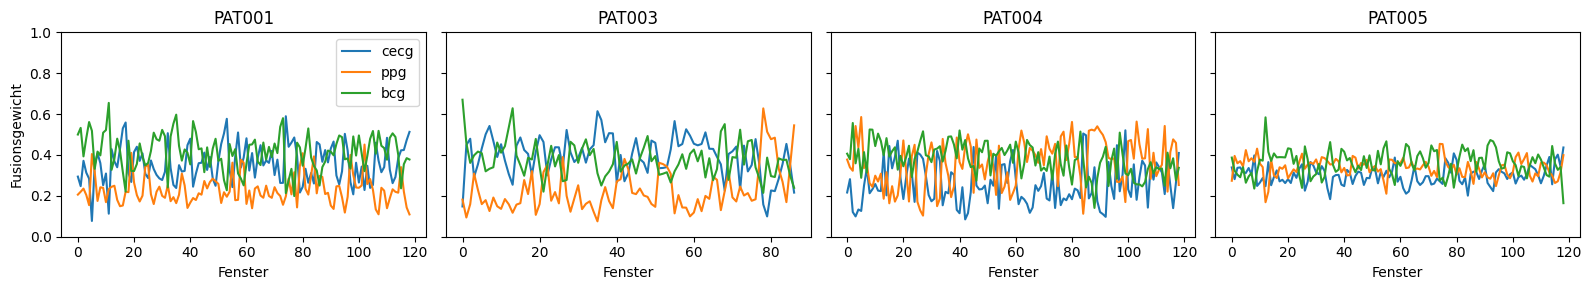

In [11]:
import matplotlib.pyplot as plt
ex = list(pd.unique(W['patient']))[:4]            # vier Beispiel-Patienten
fig, axes = plt.subplots(1, len(ex), figsize=(4 * len(ex), 3), sharey=True)
for ax, pid in zip(np.atleast_1d(axes), ex):
    sub = W[W['patient'] == pid]
    for m in G.ORDER:
        ax.plot(range(len(sub)), sub[f'w_{m}'].values, label=m)
    ax.set_title(pid); ax.set_xlabel('Fenster'); ax.set_ylim(0, 1)
np.atleast_1d(axes)[0].set_ylabel('Fusionsgewicht'); np.atleast_1d(axes)[0].legend()
plt.tight_layout(); plt.show()

In [12]:
XGB_CLF = {'cecg': 'XGB', 'ppg': 'XGB', 'bcg': 'XGB'}

# Cache ist nach clf verschlüsselt -> für XGB neu bauen (eigene Datei, LR-Cache bleibt)
fold_cache_xgb = CV.precompute_folds(df, y, groups, clf_per_modality=XGB_CLF,
                                     inner_splits=5, random_state=42,
                                     n_jobs=-1, cache_dir=DATA_DIR)

# Pro-Experte OOF-AUC mit XGB  (vs. LR: cECG 0.787 / PPG 0.884 / BCG 0.680)
from sklearn.metrics import roc_auc_score
oof_xgb = X.oof_expert_probs(df, y, groups, clf_per_modality=XGB_CLF, n_splits=5)
for m in G.ORDER:
    print(f'  {m:5s}: OOF-AUC = {roc_auc_score(y, oof_xgb[f"p_{m}"]):.3f}')

# Fusions-Vergleich mit XGB-Experten (inkl. xgb-Gate aus Schritt 1)
tab_xgb = CV.compare_gates(df, rel, y, groups, gate_kinds=('equal','gb','xgb'),
                           clf_per_modality=XGB_CLF, inner_splits=5, min_spec=0.80,
                           fold_cache=fold_cache_xgb)
tab_xgb[['gate','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3)

Berechne Experten-Schicht für 40 Folds (sig=8fe760fd3261cf9d, n_jobs=-1) ...
  fertig in 40.5s · 40 Folds
  gespeichert: ../results/fold_expert_cache_8fe760fd3261cf9d.joblib
  cecg : OOF-AUC = 0.852
  ppg  : OOF-AUC = 0.838
  bcg  : OOF-AUC = 0.722


,gate,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.908,0.829,0.805,0.816,0.467
1,gb,0.911,0.851,0.787,0.818,0.441
2,xgb,0.912,0.847,0.790,0.817,0.443


In [13]:
for tm in ['cosen_err', 'drr_sd_err', 'hr_err']:
    pv = CV.gate_predictive_validity(df, rel, y, groups, gate_kind='xgb', target_metric=tm)
    print(f'\nZiel = {tm}\n{pv.round(3).to_string()}')


Ziel = cosen_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg      0.068  0.060            -0.031     4695
ppg       0.330  0.237             0.110     4381
bcg       0.104  0.100            -0.026     4699



Ziel = drr_sd_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg      0.499  0.524             0.269     4695
ppg       0.320  0.357             0.098     4381
bcg       0.110  0.111            -0.055     4699

Ziel = hr_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg      0.373  0.348             0.148     4695
ppg       0.460  0.515             0.228     4381
bcg       0.357  0.391             0.115     4699


In [14]:
# Volle XGB-Diagnose — gleiche Analysen wie für LR, nur mit XGB-Experten
adt_xgb = CV.compare_adaptivity(df, rel, y, groups, base_gate='gb',
                                target_metric='cosen_err', clf_per_modality=XGB_CLF,
                                inner_splits=5, min_spec=0.80, fold_cache=fold_cache_xgb)
print(adt_xgb[['variant','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3).to_string(index=False))

rep_xgb, W_xgb = CV.gate_weight_report(df, rel, y, groups, gate_kind='gb',
                                       target_metric='cosen_err', clf_per_modality=XGB_CLF,
                                       inner_splits=5, min_spec=0.80, fold_cache=fold_cache_xgb)
print('\n', rep_xgb.round(3).to_string())

variant   AUC  Sensitivität  Spezifität  Accuracy  threshold
  equal 0.908         0.829       0.805     0.816      0.467
 gb-fix 0.906         0.821       0.805     0.812      0.469
 gb-win 0.911         0.851       0.787     0.818      0.441

       mean_weight  std_overall  std_within_patient  cv_within_patient
cecg        0.318        0.088               0.069              0.217
ppg         0.352        0.119               0.074              0.210
bcg         0.330        0.111               0.075              0.227


In [15]:
MIX_CLF = {'cecg': 'XGB', 'ppg': 'LR', 'bcg': 'XGB'}
fold_cache_mix = CV.precompute_folds(df, y, groups, clf_per_modality=MIX_CLF,
                                     inner_splits=5, random_state=42, n_jobs=-1, cache_dir=DATA_DIR)
tab_mix = CV.compare_gates(df, rel, y, groups, gate_kinds=('equal','gb'),
                           clf_per_modality=MIX_CLF, inner_splits=5, min_spec=0.80,
                           fold_cache=fold_cache_mix)
tab_mix[['gate','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3)

Berechne Experten-Schicht für 40 Folds (sig=218cfb87ec5005d6, n_jobs=-1) ...
  fertig in 36.3s · 40 Folds
  gespeichert: ../results/fold_expert_cache_218cfb87ec5005d6.joblib


,gate,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.940,0.914,0.818,0.864,0.436
1,gb,0.935,0.918,0.792,0.852,0.416


In [16]:
# dRR-SD-Ziel: AF-Fusion ~ wie CoSEn (0.936 vs 0.937), aber SQI sagt es BESSER vorher
# (cECG r~0.45). Bringt die FENSTERWEISE Steuerung damit endlich etwas (gb-win > gb-fix)?
adt_drr = CV.compare_adaptivity(df, rel, y, groups, base_gate='gb', target_metric='drr_sd_err',
                                inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
print(adt_drr[['variant','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3).to_string(index=False))

rep_drr, _ = CV.gate_weight_report(df, rel, y, groups, gate_kind='gb', target_metric='drr_sd_err',
                                   inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
print('\n', rep_drr.round(3).to_string())

variant   AUC  Sensitivität  Spezifität  Accuracy  threshold
  equal 0.929         0.900       0.802     0.849      0.484
 gb-fix 0.938         0.916       0.794     0.853      0.470
 gb-win 0.928         0.929       0.739     0.830      0.418

       mean_weight  std_overall  std_within_patient  cv_within_patient
cecg        0.311        0.131               0.098              0.315
ppg         0.439        0.113               0.088              0.200
bcg         0.250        0.114               0.075              0.299


## Nächste Schritte

- **Klassifikator je Experte** variieren: `clf_per_modality={'cecg':'RF','ppg':'LR','bcg':'GB'}`
  an `compare_gates`/`evaluate_moe` übergeben.
- **Gate als echtes KNN** (PyTorch + Optuna) wie bei Bachelet — der sklearn-`mlp`
  ist der Einstieg; die Schnittstelle (`gating.make_gate`) bleibt gleich.
- **Erklärbarkeit**: zeigen, wovon das Gate seine Gewichte ableitet (welche SQIs
  treiben das vorhergesagte Vertrauen?) — Integrated Gradients / Permutation Importance.

**Mit Blaß bestätigen:**
1. Gate-Ziel = RR-Irregularitäts-Treue (CoSEn), nicht reiner HR-Fehler — passt das zu AF?
2. Kanal-Aggregation PPG/BCG = bester Kanal (kleinster Fehler) — oder Mittelwert?
3. Experten eingefroren, Gate darüber trainiert (B/Stacking) — wie besprochen.


In [17]:
# GT-Detektor-Güte je Fenster (Konsens mehrerer R-Zacken-Detektoren). Einmalig, gecacht.
GTQ_CACHE = os.path.join(DATA_DIR, 'gt_quality.csv')
if os.path.exists(GTQ_CACHE):
    gtq = pd.read_csv(GTQ_CACHE); print('GT-Güte-Cache geladen:', gtq.shape)
else:
    gtq = R.build_gt_quality_table(DATA_ROOT, n_jobs=8)
    gtq.to_csv(GTQ_CACHE, index=False)

print('\nGlobale GT-conf-Verteilung:')
print(gtq['gt_conf'].describe(percentiles=[.1,.25,.5,.75,.9]).round(3))
print('\nPro-Patient (schlechteste GT zuerst):')
print(R.summarize_gt_quality(gtq, conf_lo=0.80).round(3).head(12).to_string())

  PAT001: 119 Fenster
  PAT003: 87 Fenster
  PAT004: 119 Fenster
  PAT005: 119 Fenster
  PAT006: 96 Fenster
  PAT007: 119 Fenster
  PAT008: 119 Fenster
  PAT009: 119 Fenster
  PAT010: 119 Fenster
  PAT011: 119 Fenster
  PAT012: 119 Fenster
  PAT013: 119 Fenster
  PAT014: 119 Fenster
  PAT015: 119 Fenster
  PAT016: 119 Fenster
  PAT017: 119 Fenster
  PAT018: 119 Fenster
  PAT019: 119 Fenster
  PAT021: 119 Fenster
  PAT022: 119 Fenster
  PAT023: 119 Fenster
  PAT024: 119 Fenster
  PAT025: 119 Fenster
  PAT026: 119 Fenster
  PAT028: 119 Fenster
  PAT029: 115 Fenster
  PAT030: 119 Fenster
  PAT031: 119 Fenster
  PAT033: 119 Fenster
  PAT034: 119 Fenster
  PAT036: 119 Fenster
  PAT037: 119 Fenster
  PAT038: 119 Fenster
  PAT039: 119 Fenster
  PAT040: 119 Fenster
  PAT041: 119 Fenster
  PAT042: 119 Fenster
  PAT043: 119 Fenster
  PAT044: 119 Fenster
  PAT045: 119 Fenster
  gesamt 4701 Fenster · GT-conf (stark) Median 0.713 · Fallback-Übereinst. Median 0.821 · 0% Fenster mit < 2 starken Detek

In [18]:
# Ist der scheinbare Detektor-Fehler ECHT oder nur ein GT-Problem?
rel_q = rel.merge(gtq[['patient','win_idx','gt_conf']], on=['patient','win_idx'], how='left')
hi = rel_q['gt_conf'] >= 0.80
print(f'Fenster mit vertrauenswürdiger GT (gt_conf>=0.80): {hi.mean()*100:.0f}%\n')
for m in ['cecg','ppg','bcg']:
    e = rel_q[f'rel_{m}_hr_err']
    v = (rel_q[f'rel_{m}_valid'] == True)
    print(f'  {m:5s}: median hr_err  GT-gut={e[v & hi].median():6.2f} bpm  |  '
          f'GT-schlecht={e[v & ~hi].median():6.2f} bpm  (valid={v.mean()*100:.0f}%)')

Fenster mit vertrauenswürdiger GT (gt_conf>=0.80): 31%

  cecg : median hr_err  GT-gut=  2.04 bpm  |  GT-schlecht=  1.59 bpm  (valid=100%)
  ppg  : median hr_err  GT-gut=  1.47 bpm  |  GT-schlecht=  1.28 bpm  (valid=93%)
  bcg  : median hr_err  GT-gut=  6.41 bpm  |  GT-schlecht=  5.79 bpm  (valid=100%)


In [19]:
GTQ_CACHE = os.path.join(DATA_DIR, 'gt_quality.csv')   # alte Datei vorher löschen!
gtq = R.build_gt_quality_table(DATA_ROOT, n_jobs=8)
gtq.to_csv(GTQ_CACHE, index=False)
print('\nGT-conf (nur starke Detektoren):')
print(gtq['gt_conf'].describe(percentiles=[.1,.25,.5,.75,.9]).round(3))
if 'gt_fallback_agree' in gtq.columns:
    print(
        'Median Fallback-Übereinstimmung:',
        round(gtq['gt_fallback_agree'].median(), 3)
    )
else:
    print("Spalte 'gt_fallback_agree' nicht vorhanden.")
print('\nPro-Patient (schlechteste GT zuerst):')
print(R.summarize_gt_quality(gtq, conf_lo=0.80).round(3).head(12).to_string())

  PAT001: 119 Fenster
  PAT003: 87 Fenster
  PAT004: 119 Fenster
  PAT005: 119 Fenster
  PAT006: 96 Fenster
  PAT007: 119 Fenster
  PAT008: 119 Fenster
  PAT009: 119 Fenster
  PAT010: 119 Fenster
  PAT011: 119 Fenster
  PAT012: 119 Fenster
  PAT013: 119 Fenster
  PAT014: 119 Fenster
  PAT015: 119 Fenster
  PAT016: 119 Fenster
  PAT017: 119 Fenster
  PAT018: 119 Fenster
  PAT019: 119 Fenster
  PAT021: 119 Fenster
  PAT022: 119 Fenster
  PAT023: 119 Fenster
  PAT024: 119 Fenster
  PAT025: 119 Fenster
  PAT026: 119 Fenster
  PAT028: 119 Fenster
  PAT029: 115 Fenster
  PAT030: 119 Fenster
  PAT031: 119 Fenster
  PAT033: 119 Fenster
  PAT034: 119 Fenster
  PAT036: 119 Fenster
  PAT037: 119 Fenster
  PAT038: 119 Fenster
  PAT039: 119 Fenster
  PAT040: 119 Fenster
  PAT041: 119 Fenster
  PAT042: 119 Fenster
  PAT043: 119 Fenster
  PAT044: 119 Fenster
  PAT045: 119 Fenster
  gesamt 4701 Fenster · GT-conf (stark) Median 0.713 · Fallback-Übereinst. Median 0.821 · 0% Fenster mit < 2 starken Detek

In [20]:
rel_q = rel.merge(gtq[['patient','win_idx','gt_conf']], on=['patient','win_idx'], how='left')
hi = rel_q['gt_conf'] >= 0.80
print(f'Fenster mit vertrauenswürdiger GT (gt_conf>=0.80): {hi.mean()*100:.0f}%\n')
for m in ['cecg','ppg','bcg']:
    v  = (rel_q[f'rel_{m}_valid'] == True)
    he = rel_q[f'rel_{m}_hr_err']; ce = rel_q[f'rel_{m}_cosen_err']
    print(f'  {m:5s}  hr_err  gut={he[v&hi].median():5.2f} | schlecht={he[v&~hi].median():5.2f}    '
          f'cosen_err  gut={ce[v&hi].median():6.3f} | schlecht={ce[v&~hi].median():6.3f}')

Fenster mit vertrauenswürdiger GT (gt_conf>=0.80): 31%

  cecg   hr_err  gut= 2.04 | schlecht= 1.59    cosen_err  gut= 0.865 | schlecht= 0.954
  ppg    hr_err  gut= 1.47 | schlecht= 1.28    cosen_err  gut= 0.694 | schlecht= 0.636
  bcg    hr_err  gut= 6.41 | schlecht= 5.79    cosen_err  gut= 0.915 | schlecht= 0.866
